In [1]:
import easyocr
from pdf2image import convert_from_path
import numpy as np

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"  # Replace with your PDF file path
reader = easyocr.Reader(['en'])

# Convert PDF pages to images
pages = convert_from_path(pdf_path)

all_lines = []
for page in pages:
    image_np = np.array(page)
    result = reader.readtext(image_np)
    lines = [text.strip() for _, text, _ in result if text.strip()]
    all_lines.extend(lines)

joined_text = "\n".join(all_lines)
print(joined_text)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


HABESHA PETROLEUM AND PETROLEUM PRODUCTS
DISTRIBUTER
PRIVATE LIMITED COMPANY
INDEPENDENT AUDITORS' REPORT AND FINANCIAL
STATEMENTS
FOR THE
YEAR ENDED 30 JUNE 2022
Addisu Alemu Certified Audit Firm
Bole Sub
Wereda 02
Addis AbabaEthiopia
~city;
HABESHA PETROLEUM AND PETROLEUM PRODUCTS DISTRIBUTER PLC
INDEPENDENT AUDITORS' REPORT AND FINANCIAL STATEMENTS
FOR THE YEAR ENDED 30 JUNE 2022
TABEL OF CONTENTS
Company information
Statement of management's responsibilities
2
Independent auditor's report
3-4
Financial statements:
Statement of financial position
5
Statement of profit or loss and other comprehensive income
6
Statement of changes in equity
Statement of
flows
8
Notes to the financial statements
9-31
cash
Raa
Fc
(
ALEMU (
ADDISU
HABESHA PETROLEUM AND PETROLEUM PRODUCTS DISTRIBUTER PLC
INDEPENDENT AUDITORS' REPORT AND FINANCIAL STATEMENTS
FOR THE YEAR ENDED 30 JUNE 2022
COMPANY GENERAL INFORMATION
MANAGEMENT
Ato Abatneh Chanie
General Manager
Ato Abebe Beza
Finance Manager
REGISTERED OF

In [2]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np

# If tesseract is not in PATH, specify the path like this:
# pytesseract.pytesseract.tesseract_cmd = r"/usr/bin/tesseract"

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# Convert PDF pages to images
pages = convert_from_path(pdf_path)

all_lines = []
for page in pages:
    image_np = np.array(page)
    
    # Extract text directly
    text = pytesseract.image_to_string(image_np, lang='eng')
    
    # Clean and split into lines
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    all_lines.extend(lines)

joined_text = "\n".join(all_lines)
print(joined_text)


i i i in a ee on
HABESHA PETROLEUM AND PETROLEUM PRODUCTS
DISTRIBUTER PRIVATE LIMITED COMPANY
INDEPENDENT AUDITORS' REPORT AND FINANCIAL
STATEMENTS
FOR THE YEAR ENDED 30 JUNE 2022
Addisu Alemu Certified Audit Firm
Bole Sub -city, Wereda 02 s
Addis Ababa, Ethiopia
—
a oe
Sm =) ez
‘
HABESHA PETROLEUM AND PETROLEUM PRODUCTS DISTRIBUTER PLC
INDEPENDENT AUDITORS' REPORT AND FINANCIAL STATEMENTS
FOR THE YEAR ENDED 30 JUNE 2022
TABEL OF CONTENTS
Company information 1
Statement of management's responsibilities 2
Independent auditor's report 3-4
Financial statements:
Statement of financial position 5
Statement of profit or loss and other comprehensive income
Statement of changes in equity
Statement of cash flows
Notes to the financial statements
oe)
| = | =
HABESHA PETROLEUM AND PETROLEUM PRODUCTS DISTRIBUTER PLC
INDEPENDENT AUDITORS' REPORT AND FINANCIAL STATEMENTS
FOR THE YEAR ENDED 30 JUNE 2022
COMPANY GENERAL INFORMATION
MANAGEMENT Ato Abatneh Chanie General Manager
Ato Abebe Beza Finance M

In [3]:
import pytesseract
from pytesseract import Output
from pdf2image import convert_from_path
import numpy as np
import cv2
import pandas as pd

# If Tesseract is not in PATH, specify the full path:
# pytesseract.pytesseract.tesseract_cmd = r"/usr/bin/tesseract"

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# Convert PDF pages to high-DPI images for better OCR accuracy
pages = convert_from_path(pdf_path, dpi=300)

all_pages_data = []
all_lines = []

for page_num, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # --- Preprocess for OCR ---
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    # Adaptive threshold for better contrast on scanned docs
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 35, 11
    )

    # --- OCR with detailed data ---
    ocr_data = pytesseract.image_to_data(
        thresh,
        lang="eng",
        config="--psm 6",  # Assume uniform block of text
        output_type=Output.DATAFRAME
    )

    # Clean and filter
    ocr_data = ocr_data[ocr_data.text.notnull() & (ocr_data.text.str.strip() != "")]
    ocr_data["page_num"] = page_num

    all_pages_data.append(ocr_data)

    # Collect clean plain text lines
    lines = [line.strip() for line in ocr_data["text"] if line.strip()]
    all_lines.extend(lines)

# --- Save structured OCR data ---
full_data = pd.concat(all_pages_data, ignore_index=True)
full_data.to_csv("financial_statement_ocr.csv", index=False)

# --- Save cleaned plain text ---
joined_text = "\n".join(all_lines)
with open("financial_statement_clean.txt", "w") as f:
    f.write(joined_text)

print("OCR complete. Data saved to financial_statement_ocr.csv and financial_statement_clean.txt")


OCR complete. Data saved to financial_statement_ocr.csv and financial_statement_clean.txt


In [4]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import pandas as pd
import json

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

pages = convert_from_path(pdf_path, dpi=300)

all_text_parts = []
all_tables_json = []

for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # Get structured OCR data
    data = pytesseract.image_to_data(image_np, lang='eng', output_type=pytesseract.Output.DATAFRAME)
    data = data.dropna(subset=['text'])  # Remove blanks

    # Separate table-like content from narrative text
    # Heuristic: Table rows have multiple aligned numeric columns
    table_candidates = data[data['text'].str.match(r'^[0-9,.\-]+$') | data['text'].str.match(r'^[A-Za-z].*')]
    
    # Group by 'top' position to form rows (tolerance for row height differences)
    rows = []
    current_row = []
    last_top = None
    tolerance = 10  # pixels

    for _, word in table_candidates.sort_values(by=['top', 'left']).iterrows():
        if last_top is None or abs(word['top'] - last_top) <= tolerance:
            current_row.append(word['text'])
            last_top = word['top']
        else:
            rows.append(current_row)
            current_row = [word['text']]
            last_top = word['top']
    if current_row:
        rows.append(current_row)

    # If rows look like tables (more than 2 columns), store in JSON
    table_json = []
    for r in rows:
        if len(r) >= 3:  # heuristic: table has >= 3 columns
            table_json.append(r)

    if table_json:
        all_tables_json.append({
            "page": page_index,
            "table": table_json
        })

    # Get plain text for narrative parts
    plain_text = pytesseract.image_to_string(image_np, lang='eng')
    all_text_parts.append(plain_text)

# Save results
with open("financial_tables.json", "w") as f:
    json.dump(all_tables_json, f, indent=2)

with open("narrative_text.txt", "w") as f:
    f.write("\n".join(all_text_parts))

print("Tables JSON saved to financial_tables.json")
print("Narrative text saved to narrative_text.txt")


Tables JSON saved to financial_tables.json
Narrative text saved to narrative_text.txt


In [5]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import json

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

pages = convert_from_path(pdf_path, dpi=300)
all_lines_json = []

for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # Get structured OCR data
    ocr_df = pytesseract.image_to_data(image_np, lang='eng', output_type=pytesseract.Output.DATAFRAME)
    ocr_df = ocr_df.dropna(subset=['text'])

    # Group by line number
    for line_num, line_words in ocr_df.groupby("line_num"):
        sentence = " ".join(line_words.sort_values(by="left")['text'])
        if sentence.strip():
            all_lines_json.append({
                "page": page_index,
                "line": sentence
            })

# Save to JSON
with open("financial_lines.json", "w") as f:
    json.dump(all_lines_json, f, indent=2)

print("Saved all document lines into financial_lines.json")


Saved all document lines into financial_lines.json


In [20]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import json

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 6'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)
all_lines_json = []

for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # Get structured OCR data with custom OEM & PSM config
    ocr_df = pytesseract.image_to_data(
        image_np,
        lang='eng',
        config=custom_oem_psm_config,
        output_type=pytesseract.Output.DATAFRAME
    )
    ocr_df = ocr_df.dropna(subset=['text'])

    # Group by line number
    for line_num, line_words in ocr_df.groupby("line_num"):
        sentence = " ".join(line_words.sort_values(by="left")['text'])
        if sentence.strip():
            all_lines_json.append({
                "page": page_index,
                "line": sentence
            })

# Save to JSON
with open("financial_lines_psm6.json", "w") as f:
    json.dump(all_lines_json, f, indent=2)

print("Saved all document lines into financial_lines.json")


Saved all document lines into financial_lines.json


In [1]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import json

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2021 Audittors report and Financial Statments.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 6'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)
all_lines_json = []

for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # Get structured OCR data with custom OEM & PSM config
    ocr_df = pytesseract.image_to_data(
        image_np,
        lang='eng',
        config=custom_oem_psm_config,
        output_type=pytesseract.Output.DATAFRAME
    )
    ocr_df = ocr_df.dropna(subset=['text'])

    # Group by line number
    for line_num, line_words in ocr_df.groupby("line_num"):
        sentence = " ".join(line_words.sort_values(by="left")['text'])
        if sentence.strip():
            all_lines_json.append({
                "page": page_index,
                "line": sentence
            })

# Save to JSON
with open("financial_lines_psm6_2021.json", "w") as f:
    json.dump(all_lines_json, f, indent=2)

print("Saved all document lines into financial_lines.json")


Saved all document lines into financial_lines.json


In [1]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import cv2

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 6'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)

def ocr_table_score(ocr_df):
    """Simple heuristic: small text, many words, multiple columns"""
    if ocr_df.empty:
        return 0
    avg_word_len = ocr_df['text'].str.len().mean()
    box_count = len(ocr_df)
    column_positions = ocr_df['left'] // 50
    unique_columns = column_positions.nunique()

    score = 0
    if avg_word_len < 6:
        score += 1
    if box_count > 50:
        score += 1
    if unique_columns > 3:
        score += 1
    return score / 3  # normalize 0..1

def line_table_score(image_np):
    """Detect horizontal and vertical lines as table indicators"""
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)[1]

    # Horizontal lines
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel)

    # Vertical lines
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    vertical_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel)

    # Count non-zero pixels
    h_count = cv2.countNonZero(horizontal_lines)
    v_count = cv2.countNonZero(vertical_lines)

    score = 0
    if h_count > 500:
        score += 0.5
    if v_count > 500:
        score += 0.5
    return score  # 0..1

# Analyze all pages
pages_with_tables = []
for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # OCR-based score
    ocr_df = pytesseract.image_to_data(
        image_np,
        lang='eng',
        config=custom_oem_psm_config,
        output_type=pytesseract.Output.DATAFRAME
    ).dropna(subset=['text'])
    ocr_score = ocr_table_score(ocr_df)

    # Line-based score
    line_score = line_table_score(image_np)

    # Combined confidence
    combined_score = (ocr_score + line_score) / 2

    # Threshold to flag table pages
    if combined_score > 0.4:
        pages_with_tables.append((page_index, combined_score))

# Print results
print("Pages likely containing tables (with confidence score):")
for page, score in pages_with_tables:
    print(f"Page {page}: {score:.2f}")


Pages likely containing tables (with confidence score):
Page 1: 0.83
Page 2: 1.00
Page 3: 1.00
Page 4: 1.00
Page 5: 1.00
Page 6: 1.00
Page 7: 1.00
Page 8: 1.00
Page 9: 1.00
Page 10: 1.00
Page 11: 1.00
Page 12: 1.00
Page 13: 1.00
Page 14: 1.00
Page 15: 1.00
Page 16: 1.00
Page 17: 1.00
Page 18: 1.00
Page 19: 1.00
Page 20: 1.00
Page 21: 1.00
Page 22: 1.00
Page 23: 1.00
Page 24: 1.00
Page 25: 1.00
Page 26: 1.00
Page 27: 1.00
Page 28: 1.00
Page 29: 1.00
Page 30: 1.00
Page 31: 1.00
Page 32: 1.00
Page 33: 1.00
Page 34: 1.00
Page 35: 1.00


In [2]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import cv2

# ==== CONFIG ====
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
custom_oem_psm_config = r'--oem 3 --psm 6'  # Good for table detection
dpi = 300
edge_mask_px = 50  # mask from left/right edges to avoid staple holes
min_line_length_px = 200  # filter out small lines (staple holes)
table_conf_threshold = 0.4  # combined score threshold

# ==== HELPERS ====
def ocr_table_score(ocr_df):
    """Simple heuristic: short words, many boxes, multiple columns."""
    if ocr_df.empty:
        return 0
    avg_word_len = ocr_df['text'].str.len().mean()
    box_count = len(ocr_df)
    column_positions = ocr_df['left'] // 50
    unique_columns = column_positions.nunique()

    score = 0
    if avg_word_len < 6:
        score += 1
    if box_count > 50:
        score += 1
    if unique_columns > 3:
        score += 1
    return score / 3  # normalize to 0..1

def line_table_score(image_np):
    """Detect long horizontal/vertical lines while avoiding staple holes."""
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)[1]

    # Mask page edges to avoid staple holes
    h, w = thresh.shape
    mask = np.zeros_like(thresh)
    mask[:, edge_mask_px:w - edge_mask_px] = 255  # keep center, cut edges
    thresh = cv2.bitwise_and(thresh, mask)

    score = 0

    # Horizontal lines
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    horizontal_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel)
    contours, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    long_horizontal = [c for c in contours if cv2.boundingRect(c)[2] > min_line_length_px]
    if len(long_horizontal) > 1:
        score += 0.5

    # Vertical lines
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    vertical_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel)
    contours, _ = cv2.findContours(vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    long_vertical = [c for c in contours if cv2.boundingRect(c)[3] > min_line_length_px]
    if len(long_vertical) > 1:
        score += 0.5

    return score  # 0..1

# ==== MAIN ====
pages = convert_from_path(pdf_path, dpi=dpi)
pages_with_tables = []

for page_index, page in enumerate(pages, start=1):
    image_np = np.array(page)

    # OCR-based score
    ocr_df = pytesseract.image_to_data(
        image_np,
        lang='eng',
        config=custom_oem_psm_config,
        output_type=pytesseract.Output.DATAFRAME
    ).dropna(subset=['text'])
    ocr_score = ocr_table_score(ocr_df)

    # Line-based score
    line_score = line_table_score(image_np)

    # Combined confidence
    combined_score = (ocr_score + line_score) / 2

    if combined_score > table_conf_threshold:
        pages_with_tables.append((page_index, combined_score))

# ==== RESULTS ====
print("Pages likely containing tables (with confidence score):")
for page, score in pages_with_tables:
    print(f"Page {page}: {score:.2f}")


Pages likely containing tables (with confidence score):
Page 2: 0.75
Page 3: 0.75
Page 4: 0.75
Page 5: 0.75
Page 6: 0.75
Page 7: 1.00
Page 8: 1.00
Page 9: 0.75
Page 10: 0.75
Page 11: 0.75
Page 12: 0.75
Page 13: 0.75
Page 14: 0.75
Page 15: 0.75
Page 16: 0.75
Page 17: 0.75
Page 18: 0.75
Page 19: 0.75
Page 20: 1.00
Page 21: 1.00
Page 22: 1.00
Page 23: 1.00
Page 24: 1.00
Page 25: 0.75
Page 26: 1.00
Page 27: 1.00
Page 28: 1.00
Page 29: 1.00
Page 30: 1.00
Page 31: 0.75
Page 32: 1.00
Page 33: 0.75
Page 34: 1.00
Page 35: 1.00


In [3]:
import cv2
import numpy as np
from pdf2image import convert_from_path
import tempfile
import os

def detect_table_pages(pdf_path, min_lines=3, min_line_length_ratio=0.3):
    """
    Detects pages with table-like structures based on horizontal lines.
    Works well for financial statements with mostly horizontal lines.
    """
    table_pages = []
    with tempfile.TemporaryDirectory() as temp_dir:
        images = convert_from_path(pdf_path, dpi=300, output_folder=temp_dir)

        for page_num, pil_img in enumerate(images, start=1):
            img = np.array(pil_img)
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            # Threshold (adaptive handles shadows & uneven lighting)
            binary = cv2.adaptiveThreshold(~gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                           cv2.THRESH_BINARY, 15, -2)

            # Extract horizontal lines
            horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
            horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)

            # Find contours of the lines
            contours, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            page_width = img.shape[1]
            min_line_length = page_width * min_line_length_ratio

            long_lines = [cnt for cnt in contours if cv2.boundingRect(cnt)[2] > min_line_length]

            if len(long_lines) >= min_lines:
                table_pages.append(page_num)

            # Debug visualization (optional)
            # debug_img = img.copy()
            # cv2.drawContours(debug_img, long_lines, -1, (0, 0, 255), 2)
            # cv2.imwrite(f"debug_page_{page_num}.png", debug_img)

    return table_pages

# Example usage
pdf_file = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
pages_with_tables = detect_table_pages(pdf_file)
print("Pages with tables:", pages_with_tables)


Pages with tables: [2, 4, 6, 7, 8, 9, 19, 21, 23, 27, 33, 34]


In [8]:
import cv2
import numpy as np
from pdf2image import convert_from_path
import tempfile

def detect_table_pages_filtered(pdf_path, min_lines=3, min_line_length_ratio=0.05, margin_ratio=0.05, max_thickness=5):
    """
    Detects pages with table-like structures based on horizontal & vertical lines.
    Filters out header/footer lines, edge shadows, and thick artifacts.
    """
    table_pages = []
    with tempfile.TemporaryDirectory() as temp_dir:
        images = convert_from_path(pdf_path, dpi=300, output_folder=temp_dir)

        for page_num, pil_img in enumerate(images, start=1):
            img = np.array(pil_img)
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            binary = cv2.adaptiveThreshold(~gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                           cv2.THRESH_BINARY, 15, -2)

            page_h, page_w = img.shape[:2]
            min_line_length_h = page_w * min_line_length_ratio
            min_line_length_v = page_h * min_line_length_ratio
            margin_x = int(page_w * margin_ratio)
            margin_y = int(page_h * margin_ratio)

            def filter_lines(contours, min_len, is_horizontal=True):
                filtered = []
                for cnt in contours:
                    x, y, w, h = cv2.boundingRect(cnt)

                    # Skip too thick lines
                    thickness = h if is_horizontal else w
                    if thickness > max_thickness:
                        continue

                    # Skip lines near page edges
                    if is_horizontal:
                        if y < margin_y or y + h > page_h - margin_y:
                            continue
                        if w < min_len:
                            continue
                    else:
                        if x < margin_x or x + w > page_w - margin_x:
                            continue
                        if h < min_len:
                            continue

                    filtered.append(cnt)
                return filtered

            # Detect horizontal
            horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
            horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
            contours_h, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            long_h_lines = filter_lines(contours_h, min_line_length_h, is_horizontal=True)

            # Detect vertical
            vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
            vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)
            contours_v, _ = cv2.findContours(vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            long_v_lines = filter_lines(contours_v, min_line_length_v, is_horizontal=False)

            total_lines = len(long_h_lines) + len(long_v_lines)

            if total_lines >= min_lines:
                table_pages.append(page_num)

            # Optional debug
            debug_img = img.copy()
            cv2.drawContours(debug_img, long_h_lines, -1, (0, 0, 255), 2)  # Horizontal = red
            cv2.drawContours(debug_img, long_v_lines, -1, (0, 255, 0), 2)  # Vertical = green
            cv2.imwrite(f"debug_filtered_page_{page_num}.png", debug_img)

    return table_pages

# Example usage
pdf_file = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
pages_with_tables = detect_table_pages_filtered(pdf_file)
print("Pages with tables:", pages_with_tables)


Pages with tables: [7, 20, 21, 23, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [10]:
import cv2
import numpy as np
from pdf2image import convert_from_path
import tempfile

def detect_table_pages_filtered(pdf_path, min_lines=3,
                                min_line_length_ratio=0.05,  # short lines allowed
                                margin_ratio=0.05, max_thickness=5):
    """
    Detects pages with table-like structures using horizontal + vertical lines.
    - Keeps shorter lines (>= 5% of page dimension).
    - Filters out header/footer lines, page edge shadows, and very thick lines.
    """
    table_pages = []
    with tempfile.TemporaryDirectory() as temp_dir:
        images = convert_from_path(pdf_path, dpi=300, output_folder=temp_dir)

        for page_num, pil_img in enumerate(images, start=1):
            img = np.array(pil_img)
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            # Binarize & invert
            binary = cv2.adaptiveThreshold(~gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                           cv2.THRESH_BINARY, 15, -2)

            page_h, page_w = img.shape[:2]
            min_len_h = page_w * min_line_length_ratio
            min_len_v = page_h * min_line_length_ratio
            margin_x = int(page_w * margin_ratio)
            margin_y = int(page_h * margin_ratio)

            def filter_lines(contours, min_len, is_horizontal=True):
                filtered = []
                for cnt in contours:
                    x, y, w, h = cv2.boundingRect(cnt)

                    thickness = h if is_horizontal else w
                    if thickness > max_thickness:
                        continue  # skip very thick lines

                    if is_horizontal:
                        if w < min_len:
                            continue
                        if y < margin_y or y + h > page_h - margin_y:
                            continue
                    else:
                        if h < min_len:
                            continue
                        if x < margin_x or x + w > page_w - margin_x:
                            continue

                    filtered.append(cnt)
                return filtered

            # --- Horizontal lines ---
            horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
            horizontal_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)
            contours_h, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            long_h_lines = filter_lines(contours_h, min_len_h, True)

            # --- Vertical lines ---
            vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
            vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)
            contours_v, _ = cv2.findContours(vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            long_v_lines = filter_lines(contours_v, min_len_v, False)

            total_lines = len(long_h_lines) + len(long_v_lines)

            if total_lines >= min_lines:
                table_pages.append(page_num)

            # --- Debug visualization ---
            debug_img = img.copy()
            cv2.drawContours(debug_img, long_h_lines, -1, (0, 0, 255), 2)  # Red = horizontal
            cv2.drawContours(debug_img, long_v_lines, -1, (0, 255, 0), 2)  # Green = vertical
            cv2.imwrite(f"debug_page_{page_num}.png", debug_img)

    return table_pages

# Example usage
pdf_file = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
pages_with_tables = detect_table_pages_filtered(pdf_file)
print("Pages with tables:", pages_with_tables)


Pages with tables: [7, 20, 21, 23, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [11]:
import cv2
import numpy as np
import fitz  # PyMuPDF
import os

# === CONFIG ===
PDF_PATH = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
OUTPUT_DIR = "pdf_lines_debug"
DPI = 300
EDGE_MARGIN = 15  # pixels from border to ignore lines

# Create output dir
os.makedirs(OUTPUT_DIR, exist_ok=True)

# === Convert PDF to images ===
doc = fitz.open(PDF_PATH)
for page_index in range(len(doc)):
    pix = doc[page_index].get_pixmap(dpi=DPI)
    img_path = os.path.join(OUTPUT_DIR, f"page_{page_index+1}.png")
    pix.save(img_path)

    # === Read page image ===
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert + threshold
    gray = cv2.bitwise_not(gray)
    bw = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY, 15, -2
    )

    height, width = bw.shape
    min_horizontal_len = int(width * 0.3)
    min_vertical_len = int(height * 0.3)

    # === Horizontal detection ===
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    detect_horizontal = cv2.morphologyEx(bw, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)

    contours, _ = cv2.findContours(detect_horizontal, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > min_horizontal_len and EDGE_MARGIN < x < width - EDGE_MARGIN:
            cv2.line(image, (x, y), (x + w, y), (0, 0, 255), 2)

    # === Vertical detection ===
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    detect_vertical = cv2.morphologyEx(bw, cv2.MORPH_OPEN, vertical_kernel, iterations=2)

    contours, _ = cv2.findContours(detect_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > min_vertical_len and EDGE_MARGIN < x < width - EDGE_MARGIN:
            cv2.line(image, (x, y), (x, y + h), (255, 0, 0), 2)

    # Save debug image
    output_img_path = os.path.join(OUTPUT_DIR, f"page_{page_index+1}_lines.png")
    cv2.imwrite(output_img_path, image)

print(f"Processing complete. Debug images saved in: {OUTPUT_DIR}")


Processing complete. Debug images saved in: pdf_lines_debug


In [12]:
import cv2
import numpy as np
import fitz  # PyMuPDF
import os

# === CONFIG ===
PDF_PATH = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"
OUTPUT_DIR = "pdf_lines_debug"
DPI = 300
EDGE_MARGIN = 15  # Ignore lines close to edges
MIN_LINES_FOR_TABLE = 2  # Minimum vertical AND horizontal lines to consider page as table

# Create output dir
os.makedirs(OUTPUT_DIR, exist_ok=True)

table_pages = []  # store page indexes with tables

doc = fitz.open(PDF_PATH)
for page_index in range(len(doc)):
    # === PDF page to image ===
    pix = doc[page_index].get_pixmap(dpi=DPI)
    img_path = os.path.join(OUTPUT_DIR, f"page_{page_index+1}.png")
    pix.save(img_path)

    # === Read image ===
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Threshold
    gray = cv2.bitwise_not(gray)
    bw = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY, 15, -2
    )

    height, width = bw.shape
    min_horizontal_len = int(width * 0.3)
    min_vertical_len = int(height * 0.3)

    horizontal_count = 0
    vertical_count = 0

    # === Horizontal lines ===
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    detect_horizontal = cv2.morphologyEx(bw, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)

    contours, _ = cv2.findContours(detect_horizontal, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > min_horizontal_len and EDGE_MARGIN < x < width - EDGE_MARGIN:
            horizontal_count += 1
            cv2.line(image, (x, y), (x + w, y), (0, 0, 255), 2)

    # === Vertical lines ===
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    detect_vertical = cv2.morphologyEx(bw, cv2.MORPH_OPEN, vertical_kernel, iterations=2)

    contours, _ = cv2.findContours(detect_vertical, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if h > min_vertical_len and EDGE_MARGIN < x < width - EDGE_MARGIN:
            vertical_count += 1
            cv2.line(image, (x, y), (x, y + h), (255, 0, 0), 2)

    # Check if page likely contains table
    if horizontal_count >= MIN_LINES_FOR_TABLE and vertical_count >= MIN_LINES_FOR_TABLE:
        table_pages.append(page_index + 1)  # human-readable numbering

    # Save debug image
    output_img_path = os.path.join(OUTPUT_DIR, f"page_{page_index+1}_lines.png")
    cv2.imwrite(output_img_path, image)

# === Print summary ===
print(f"Pages with tables (approx): {table_pages}")


Pages with tables (approx): [1, 2, 5, 7, 8, 19, 20, 21, 27, 28, 34]


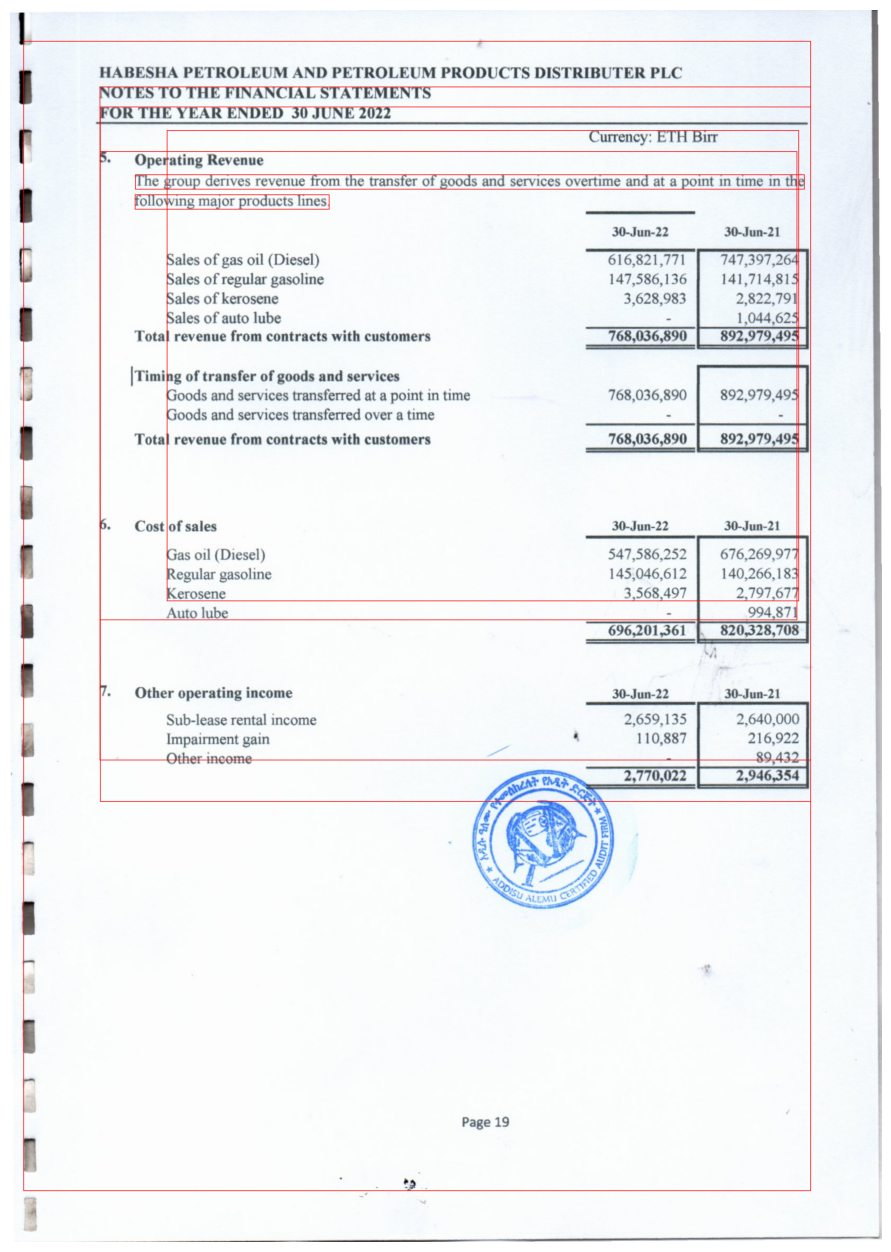

In [9]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import json
import matplotlib.pyplot as plt
from PIL import ImageDraw

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 4'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)

# Choose the page number you want to visualize (1-based)
page_num_to_visualize = 20  # Example: 2nd page

# Get that page image
page_img = pages[page_num_to_visualize - 1]
image_np = np.array(page_img)

# OCR with bounding boxes
ocr_df = pytesseract.image_to_data(
    image_np,
    lang='eng',
    config=custom_oem_psm_config,
    output_type=pytesseract.Output.DATAFRAME
)
ocr_df = ocr_df.dropna(subset=['text'])

# Draw bounding boxes for each line
draw = ImageDraw.Draw(page_img)

for line_num, line_words in ocr_df.groupby("line_num"):
    # Calculate bounding box for the whole line
    x1 = line_words['left'].min()
    y1 = line_words['top'].min()
    x2 = (line_words['left'] + line_words['width']).max()
    y2 = (line_words['top'] + line_words['height']).max()
    
    # Draw red rectangle
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

# Show with matplotlib
plt.figure(figsize=(12, 16))
plt.imshow(page_img)
plt.axis('off')
plt.show()


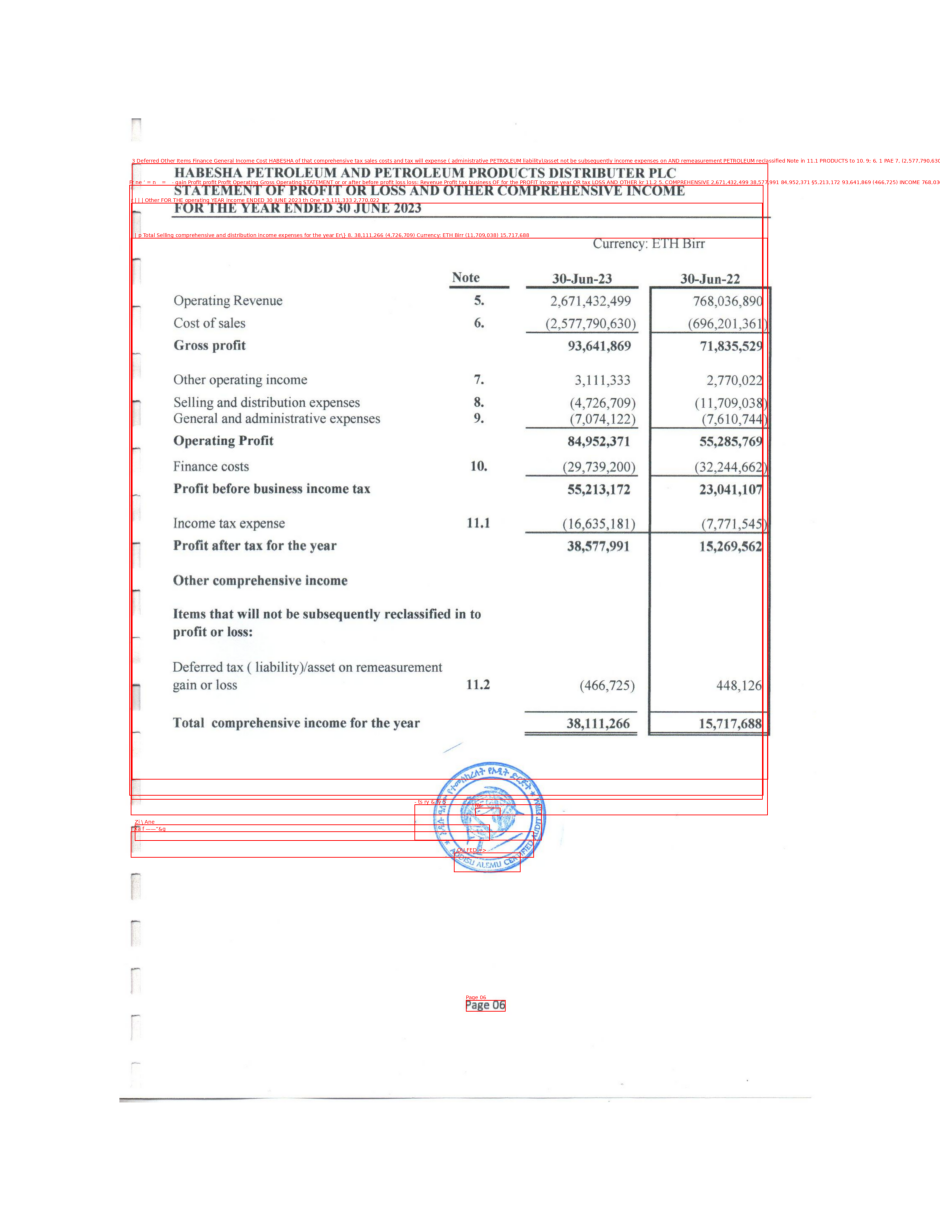

: 

In [ ]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2023 Auditors repor and financial statements .pdf"

# OCR configuration
# custom_oem_psm_config = r'--oem 3 --psm 4'
custom_oem_psm_config = r'--oem 3 --psm 6'
# custom_oem_psm_config = r'--oem 3 --psm 11'  # Sparse text, find as much as possible
  # Assume a single uniform block of text


# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)

# Choose the page number you want to visualize (1-based)
page_num_to_visualize = 7  # Example: 2nd page

# Get that page image
page_img = pages[page_num_to_visualize - 1]
image_np = np.array(page_img)

# OCR with bounding boxes
ocr_df = pytesseract.image_to_data(
    image_np,
    lang='eng',
    config=custom_oem_psm_config,
    output_type=pytesseract.Output.DATAFRAME
)
ocr_df = ocr_df.dropna(subset=['text'])

# print(ocr_df.head())

# Draw bounding boxes and text
draw = ImageDraw.Draw(page_img)

# Optional: You can set a font (fallback to default if not found)
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 14)
except:
    font = ImageFont.load_default()

for line_num, line_words in ocr_df.groupby("line_num"):
    sentence = " ".join(line_words.sort_values(by="left")['text'])
    x1 = line_words['left'].min()
    y1 = line_words['top'].min()
    x2 = (line_words['left'] + line_words['width']).max()
    y2 = (line_words['top'] + line_words['height']).max()

    # Draw red rectangle
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

    # Draw text label above the box (in yellow for visibility)
    draw.text((x1, y1 - 15), sentence, fill="red", font=font)

# Show with matplotlib
plt.figure(figsize=(12, 16))
plt.imshow(page_img)
plt.axis('off')
plt.show()


In [16]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 4'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)

# Pages to extract coordinates from (1-based indexing)
pages_to_extract = [20]  # Example: page 2 and page 4

for page_num in pages_to_extract:
    page_img = pages[page_num - 1]
    image_np = np.array(page_img)

    # OCR with bounding boxes
    ocr_df = pytesseract.image_to_data(
        image_np,
        lang='eng',
        config=custom_oem_psm_config,
        output_type=pytesseract.Output.DATAFRAME
    )
    ocr_df = ocr_df.dropna(subset=['text'])

    print(f"\n=== Page {page_num} ===")
    for line_num, line_words in ocr_df.groupby("line_num"):
        sentence = " ".join(line_words.sort_values(by="left")['text'])
        x1 = int(line_words['left'].min())
        y1 = int(line_words['top'].min())
        x2 = int((line_words['left'] + line_words['width']).max())
        y2 = int((line_words['top'] + line_words['height']).max())

        print({
            "page": page_num,
            "line_text": sentence,
            "coordinates": {"x1": x1, "y1": y1, "x2": x2, "y2": y2}
        })



=== Page 20 ===
{'page': 20, 'line_text': 'ees 6. HABESHA 7. |Timing Total Cost Other Sales Sales Sales Other of revenue operating PETROLEUM sales of transfer of of of income regular auto kerosene from income lube of contracts gasoline goods AND and with PETROLEUM services customers t PRODUCTS Page    / 19 DISTRIBUTER   696,201,361 768,036,890 147,586,136 30-Jun-22 30-Jun-22 30-Jun-22 "2,770,022 3,628,983 PLC -                  | | 820,328,708 892,979,495 892,979,495 141,714,815 30-Jun-21 30-Jun-21 30-Jun-21 2,822,791 2,946,354 1,044,625 89,432    ', 'coordinates': {'x1': 38, 'y1': 88, 'x2': 2278, 'y2': 3361}}
{'page': 20, 'line_text': 'NOTES Total TO Goods Gas Sales Sub-lease revenue THE oil of and (Diesel) gas FINANCIAL from rental services oil contracts (Diesel) income transferred STATEMENTS with customers at a point in time 768,036,890 547,586,252 616,821,771 768,036,890 2,659,135      676,269,977 747,397,264 2,640,000       ', 'coordinates': {'x1': 255, 'y1': 218, 'x2': 2278, 'y2

In [ ]:
import pytesseract
from pdf2image import convert_from_path
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont

# PDF path
pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2022 Audite repor.pdf"

# OCR configuration
custom_oem_psm_config = r'--oem 3 --psm 4'

# Convert PDF to images
pages = convert_from_path(pdf_path, dpi=300)

# Choose the page number you want to visualize (1-based)
page_num_to_visualize = 2  # Example: 2nd page

# Get that page image
page_img = pages[page_num_to_visualize - 1]
image_np = np.array(page_img)

# OCR with bounding boxes
ocr_df = pytesseract.image_to_data(
    image_np,
    lang='eng',
    config=custom_oem_psm_config,
    output_type=pytesseract.Output.DATAFRAME
)
ocr_df = ocr_df.dropna(subset=['text'])

# Draw bounding boxes and text
draw = ImageDraw.Draw(page_img)

# Optional: You can set a font (fallback to default if not found)
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 14)
except:
    font = ImageFont.load_default()

for line_num, line_words in ocr_df.groupby("line_num"):
    sentence = " ".join(line_words.sort_values(by="left")['text'])
    x1 = line_words['left'].min()
    y1 = line_words['top'].min()
    x2 = (line_words['left'] + line_words['width']).max()
    y2 = (line_words['top'] + line_words['height']).max()

    # Draw red rectangle
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

    # Draw text label above the box (in yellow for visibility)
    draw.text((x1, y1 - 15), sentence, fill="yellow", font=font)

# Show with matplotlib
plt.figure(figsize=(12, 16))
plt.imshow(page_img)
plt.axis('off')
plt.show()


In [5]:
import fitz  # PyMuPDF

doc = fitz.open("/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2024_audited.pdf")
all_text = []
for page in doc:
    all_text.append(page.get_text())
joined_text = "\n".join(all_text)
print(joined_text)

In [6]:
import pdfplumber

pdf_path = "/home/name-1/AI-Agent/new-born/data/FINANC AUDIT 2 (1)/FINANC AUDIT 2/2024_audited.pdf"

with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start=1):
        tables = page.extract_tables()
        for table_num, table in enumerate(tables, start=1):
            print(f"Page {page_num}, Table {table_num}:")
            for row in table:
                print(row)
            print("-" * 40)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

In [1]:
# /home/name-1/AI-Agent/new-born/data/Kedir Jara CBE Statement.pdf
import pdfplumber

pdf_path = "/home/name-1/AI-Agent/new-born/data/Kedir Jara CBE Statement.pdf"

with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start=1):
        tables = page.extract_tables()
        for table_num, table in enumerate(tables, start=1):
            print(f"Page {page_num}, Table {table_num}:")
            for row in table:
                print(row)
            print("-" * 40)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def